# Creates combined LULUCF tables (long and wide format)

Table manipulation from Claude session 'LULUCF and component table creation'

This involves giant tables, so some steps take many minutes. The longest step is converting the long-format veg tile-level tables to wide-format (>1 hr). 
Also, because this involves giant tables, it uses a lot of memory and doesn't seem to be able to run beginning to end on my computer; the kernel keeps crashing at one point or another. 
But by running a few steps, saving intermediate outputs to parquet, letting the kernel crash when it wants and then continuing by reading the parquets I saved, it's gotten all the way through.  

In [2]:
import pandas as pd
import yaml
import geodatasets
import geopandas as gpd
import math
import rasterio
import os
import openpyxl
import pygwalker as pyg
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.lines as mlines
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import re
import glob
import gc
import sys
import textwrap
from shapely.geometry import Point
from datetime import datetime
from pathlib import Path
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator
from matplotlib.transforms import blended_transform_factory
from matplotlib.gridspec import GridSpec
from io import BytesIO
from IPython.display import Image, display as ipy_display
from rasterio.windows import Window
from tqdm import tqdm

In [3]:
# To add project files
# Keeps going up project structure until it gets to the root.
# Per https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c-afolu-flux-model/c/69a5ff07-91e0-8329-88d1-cf2ea6c159c2
project_root = Path().resolve()
while project_root.name != "AFOLU_GHG_flux_model":
    project_root = project_root.parent

sys.path.append(str(project_root))

from src.utilities import constants_and_names as cn
from src.utilities import universal_utilities as uu

now = datetime.now()
today = now.strftime("%Y%m%d")

pd.set_option('display.max_columns', None)

### Input table paths (zonal stats, and chunk stats for comparison purposes)

In [4]:
# Vegetation zonal stats output folder (separate parquet for each tile-- too large to combine into a single long-format parquet)
veg_zonal_stats_folder = f'/mnt/c/GIS/AFOLU_flux_model/LULUCF/zonal_statistics/vegetation_v{cn.veg_model_version_underscore}_standard_global__full_run_with_Canada_rerun__20260603/'

veg_wide_folder = f'{veg_zonal_stats_folder}wide_tiles/'
os.makedirs(veg_wide_folder, exist_ok=True)

In [5]:
veg_parquet_files = sorted(glob.glob(f'{veg_zonal_stats_folder}*.parquet'))
# veg_parquet_files_subset = veg_parquet_files[0:5]
print(f"Found {len(veg_parquet_files)} parquet files")

Found 357 parquet files


In [6]:
# SOC (including mineral soil) zonal stats output
SOC_zonal_stats_folder = f'/mnt/c/GIS/AFOLU_flux_model/LULUCF/zonal_statistics/SOC_v{cn.SOC_model_version_underscore}_standard_global/'
SOC_parquet_name = f'SOC_zonal_stats_v{cn.SOC_model_version_underscore}_20260531_21_15_30.parquet'

In [7]:
# Organic soil zonal stats output
org_soil_zonal_stats_folder = f'/mnt/c/GIS/AFOLU_flux_model/LULUCF/zonal_statistics/organic_soil_v1_0_1_standard_global__20260604/'
org_soil_parquet_name = 'master_zonal_full_disaggregation.parquet'  

In [8]:
# LULUCF outputs
LULUCF_zonal_stats_folder = Path(f'/mnt/c/GIS/AFOLU_flux_model/LULUCF/zonal_statistics/LULUCF_v{cn.LULUCF_model_version_underscore}__veg_v{cn.veg_model_version_underscore}__minsoil_v{cn.SOC_model_version_underscore}__orgsoil_v{cn.organic_soil_model_version_underscore}/')
LULUCF_zonal_stats_folder.mkdir(parents=True, exist_ok=True)
LULUCF_zonal_stats_folder

PosixPath('/mnt/c/GIS/AFOLU_flux_model/LULUCF/zonal_statistics/LULUCF_v1_0_0__veg_v1_0_5__minsoil_v1_0_1__orgsoil_v1_0_1')

In [9]:
# Contextual columns for making a unified wide table format

agg_layers = ['analysis_layer', 'year', 
              'land_state_node', 'land_state_meaning', 'land_state_broad_class', 'land_state_detailed_class', 'tall_veg_type',
              'adm0', 'country_name', 'region_L1', 'region_L2_L3',
              'continent', 'ecozone', 'continent_ecozone', 'climate_domain', 'cont_eco',
              'Landmark',
              'starting_composite_primary_forest',
              'KBA',
              'watershed', 'watershed_name',
              'drivers_of_TCL_1_km', 'driver_1km_text',
              'forest_age_category_end_of_interval',
              # 'gas',
              'WDPA', 'WDPA_type', 'WDPA_high_protection'
             ]

### Global vegetation table with full contextual layers

In [ ]:
# Converts long-format parquet tables for individual tiles to wide format. Used for vegetation
def convert_indiv_tiles_to_wide(tile_parquets, context_layers, out_folder, LULUCF_component, model_version, context_layers_description):

    os.makedirs(out_folder, exist_ok=True)
    
    # Contextual columns
    contextual_cols = [c for c in context_layers if c != 'analysis_layer']

    wide_columns = []
    row_count = 0

    # Iterates through tables
    for f in tqdm(tile_parquets):
        tile_id = os.path.splitext(os.path.basename(f))[0]   # e.g. "00N_020E"
        out_path = f'{out_folder}{tile_id}_v{model_version}__{context_layers_description}__wide__{today}.parquet'
    
        if os.path.exists(out_path):
            df_check = pd.read_parquet(out_path)
            wide_columns = df_check.columns.to_list()
            row_count += len(df_check)
            continue

        # Aggregates wide table by selected contextual layers
        df_tile = pd.read_parquet(f, columns=agg_layers + ['value', 'area_ha'])
        df_tile = df_tile.drop(columns=['gas'], errors='ignore')
        agg = (
            df_tile
            .groupby(agg_layers, dropna=False)[['value', 'area_ha']]
            .sum()
            .reset_index()
        )

        # Separate processing of fluxes and areas
        flux_wide = (
            agg.set_index(contextual_cols + ['analysis_layer'])['value']
            .unstack('analysis_layer')
            .rename_axis(None, axis='columns')
            .fillna(0)
            .reset_index()
        )
        area_wide = (
            agg.set_index(contextual_cols + ['analysis_layer'])['area_ha']
            .unstack('analysis_layer')
            .add_suffix('__area_ha')
            .rename_axis(None, axis='columns')
            .fillna(0)
            .reset_index()
        )

        # Merges area and flux tables back together
        tile_wide = flux_wide.merge(area_wide, on=contextual_cols)

        # Adds LULUCF_component column
        tile_wide['LULUCF_component'] = LULUCF_component
        
        tile_wide.to_parquet(out_path, index=False)

        wide_columns = tile_wide.columns.to_list()
        row_count += len(tile_wide)

    print(f"Saved {len(tile_parquets)} wide tile parquets to {out_folder}")

    return wide_columns, row_count, contextual_cols

In [ ]:
# Combines wide-format tables for individual tiles into global composite, including reaggregating across tiles (since no tile_id field anymore). Used for vegetation
def combine_wide_files(wide_folder, main_folder, contextual_cols, out_name, version, context_layers_description):

    wide_tile_files = sorted(glob.glob(f'{wide_folder}/*wide*.parquet'))
    print(f"Found {len(wide_tile_files)} wide parquet files to combine")

    # Combines all tile tables
    print("Combining tile-level wide parquets")
    combined = pd.concat(
        [pd.read_parquet(f) for f in tqdm(wide_tile_files)],
        ignore_index=True
    )

    # Reaggregates with remaining contextual layers
    print("Reaggregating global wide parquet")
    sums_wide = (
        combined
        .groupby(contextual_cols, dropna=False)
        .sum(numeric_only=True)
        .reset_index()
    )

    sums_wide.to_parquet(f"{main_folder}/{out_name}__global__v{version}__{context_layers_description}__wide__{today}.parquet", index=False)

    return sums_wide

In [ ]:
%%time

#TODO Add veg_ to start of vegetation column names

# Converts all long parquet tables to wide
# Took 1h 5min with all contextual layers

wide_columns, row_count, contextual_cols = convert_indiv_tiles_to_wide(veg_parquet_files, agg_layers, veg_wide_folder, "veg", cn.veg_model_version_underscore, "all_layers")
print(f"Total rows across wide tiles: {row_count:}")
print(f"Contextual columns across wide tiles: {contextual_cols}")
print(f"Wide columns: {wide_columns}")

In [ ]:
%%time

# Combines all tile-level wide tables into a single global wide table and reaggregates with contextual layers (i.e. sums rows that have duplicate contextual combinations across tiles because there's no tile_id)

sums_wide = combine_wide_files(veg_wide_folder, veg_zonal_stats_folder, contextual_cols, "veg_model_zonal_stats", cn.veg_model_version_underscore, "all_layers")
print(len(sums_wide))
display(sums_wide)

### Standardizing soil tables

In [10]:
# Fills in the intervening years of the multi-year intervals for soil data (organic and mineral).
# Basically, duplicates values from end-of-interval years for all the preceding years in the interval,
# but only for that row's own nominal interval. Missing intervals stay blank.
# Per https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c-afolu-flux-model/c/69c2fe30-7004-8328-9f6d-1c231ba04e20
def fill_in_soil_years(df, group_cols, agg_first=False):

    # Aggregate first
    if agg_first:
        df = (
            df
            .groupby(group_cols, dropna=False, as_index=False)
            .agg({
                "zonal_stats_sum": "sum",
                "area_ha": "sum"
            })
        )

    # Sort by timeseries + year
    df = df.sort_values(group_cols + ["year"]).reset_index(drop=True)

    year_vals = df["year"].astype(int)

    # Maximum (final) year in the dataset
    last_year = year_vals.max()

    # Nominal interval length for each endpoint year:
    # - years divisible by 5 -> 5-year interval
    # - final year in dataset -> interval from 2021 to last_year
    # - everything else defaults to 1 year unless you add more rules
    interval_len = np.where(
        year_vals.eq(last_year),
        last_year - 2021 + 1,
        np.where(year_vals.mod(5).eq(0), 5, 1)
    )

    # Start year comes only from the row's own nominal interval,
    # not from the previous observed year.
    start_year = (year_vals - interval_len + 1).astype(int).to_numpy()
    end_year = year_vals.to_numpy()

    # Number of repetitions for each interval
    n_rep = end_year - start_year + 1

    # Duplicate rows
    expanded = df.loc[df.index.repeat(n_rep)].copy()

    # Assign correct years
    expanded["year"] = np.concatenate([
        np.arange(s, e + 1) for s, e in zip(start_year, end_year)
    ])

    expanded = expanded.reset_index(drop=True)

    # If the source data ends before the end of the vegetation timeseries, extendyears through 2024 to match vegetation timeseries
    if last_year < cn.years_annual[-1]:
        rows_2022 = expanded[expanded["year"] == 2022].copy()

        rows_2023 = rows_2022.copy()
        rows_2023["year"] = 2023

        rows_2024 = rows_2022.copy()
        rows_2024["year"] = 2024

        expanded = pd.concat([expanded, rows_2023, rows_2024], ignore_index=True)
        expanded = expanded.sort_values(group_cols + ["year"]).reset_index(drop=True)

    return expanded

In [ ]:
# Converts global long-format table to wide-format table. Used specifically for SOC.
# chunk_col argument breaks the processing up by values in the specified column because otherwise these tables are too large to pivot all at once
def global_long_to_wide(sums, agg_layers, chunk_col='cont_eco'):

    contextual_cols = [c for c in agg_layers if c != 'analysis_layer']

    # Collapse any duplicate contextual combinations before unstacking
    # (can arise when missing columns are filled with 'unassigned')
    print("  Collapsing any duplicate contextual combinations...")
    sums = (
        sums
        .groupby(contextual_cols + ['analysis_layer'], dropna=False)[['zonal_stats_sum', 'area_ha']]
        .sum()
        .reset_index()
    )


    print(f"  Pivoting flux values in chunks by {chunk_col}...")
    flux_chunks, area_chunks = [], []
    for val in tqdm(sums[chunk_col].unique()):
        chunk = sums[sums[chunk_col] == val]
        flux_chunks.append(
            chunk.set_index(contextual_cols + ['analysis_layer'])['zonal_stats_sum']
            .unstack('analysis_layer')
            .rename_axis(None, axis='columns')
        )
        area_chunks.append(
            chunk.set_index(contextual_cols + ['analysis_layer'])['area_ha']
            .unstack('analysis_layer')
            .add_suffix('__area_ha')
            .rename_axis(None, axis='columns')
        )

    print("  Concatenating and merging fluxes...")
    flux_wide = pd.concat(flux_chunks).fillna(0).reset_index()
    print("  Concatenating and merging areas...")
    area_wide = pd.concat(area_chunks).fillna(0).reset_index()
    print("  Merging...")
    sums_wide = flux_wide.merge(area_wide, on=contextual_cols)
    del flux_chunks, area_chunks, flux_wide, area_wide
    print("  Done converting to wide")

    return sums_wide

In [11]:
%%time
### Standardizes SOC table in long format.
### SOC is small enough to be combined in long format before being reshaped to wide, unlike vegetation

# Reads SOC zonal stats parquet table
SOC_df_raw = pd.read_parquet(f'{SOC_zonal_stats_folder}{SOC_parquet_name}')

# Renames value column with units
SOC_df_raw.rename(columns={'value': 'zonal_stats_sum'}, inplace=True)

print(f"Rows in SOC_df_raw: {len(SOC_df_raw)}")
SOC_df_raw


# Drops all years before vegetation data (before 2016) because we don't need those for LULUCF (i.e. keeps only the 2020 and 2022 stock and change data)
SOC_df_post_2016 = SOC_df_raw[SOC_df_raw["year"] >= cn.interval_end_years_annual[0]].reset_index(drop=True)
print(f"Rows in SOC_df_post_2016: {len(SOC_df_post_2016)}")
SOC_df_post_2016


#TODO Use only the 2020 change interval, not 2020 and 2022!!!!!!!!!!!!!

## Fills in the years for multi-year interval SOC data.
# 2020 is copied to 2016-2020 and 2022 to 2021-2024 (to match end of vegetation timeseries). 
# If a year doesn't have data for a given year and combination of contextual layers, there is nothing to expand and all years in that interval are empty.
series_cols = SOC_df_post_2016.drop(columns=['zonal_stats_sum', 'density__Mg_ha', 'area_ha']).columns.to_list()
print(series_cols)
print("Filling in soil years") 
SOC_df_post_2016_years_filled_in = fill_in_soil_years(SOC_df_post_2016, series_cols, agg_first=True)
print(f"Rows in SOC_df_post_2016_years_filled_in: {len(SOC_df_post_2016_years_filled_in)}")
# display(SOC_df_post_2016_years_filled_in)

# Ratio below Should be very close to 4.5. If every contextual combination has every year, full year expansion would be 4.5 (2020 interval expanded 5x years, 2022 expanded 4x years).
# However, some contextual combinations don't have all years (usually because they're so rare and other years have just 1 pixel of that combination),
# so that doesn't get expanded to other years. This results in deviation from the 4.25x expansion. 
print(f"Ratio of rows in unexpanded to expanded tables: {len(SOC_df_post_2016_years_filled_in)/len(SOC_df_post_2016)}")

# Information on the years included in the table
SOC_year_count = len(SOC_df_post_2016_years_filled_in['year'].unique())
print(f"Years in SOC data: {SOC_df_post_2016_years_filled_in['year'].unique()} is {SOC_year_count} years")



# TODO Currently, mineral and organic soil data is getting put under "vegetation_other" for land_state_detailed_class. It should be under "Unassigned"
# Adds contextual columns found in the vegetation table. Fills with Unassigned for text fields and -999 for numeric fields.
# Gets the data type for the fields from the vegetation table
veg_parquet_path = f'{veg_zonal_stats_folder}veg_model_zonal_stats__global__v{cn.veg_model_version_underscore}__all_layers__wide__20260605.parquet'
veg_field_types = {field.name: field.type for field in pq.read_schema(veg_parquet_path)}
contextual_cols = [c for c in agg_layers if c != 'analysis_layer']
for col in contextual_cols:
    if col not in SOC_df_post_2016_years_filled_in.columns:
        arrow_type = veg_field_types.get(col)
        is_numeric = arrow_type is not None and (pa.types.is_integer(arrow_type) or pa.types.is_floating(arrow_type))
        default = -999 if is_numeric else 'Unassigned'
        SOC_df_post_2016_years_filled_in[col] = default
        print(f"  Adding {col} with default of {default}")


# QC: Timeseries of SOC change (full and mineral extent) to compare against chunk stats (Mg CO2/yr)
# Some chunk stat values to check against: Density mineral extent 2020 = 350361333214; Net mineral extent 2020=1264590854; gain mineral extent 2020= -5495786224; loss mineral extent 2020= 6760376953
layers = [
    "SOC_density__mineral_soil_extent__0-30cm_MgC_ha",
    "SOC_gain__mineral_soil_extent__0-30cm_MgCO2",
    "SOC_loss__mineral_soil_extent__0-30cm_MgCO2",
    "SOC_net__mineral_soil_extent__0-30cm_MgCO2"
]
SOC_QC_sum = (
    SOC_df_post_2016_years_filled_in[SOC_df_post_2016_years_filled_in["analysis_layer"].isin(layers)]
    .groupby(["analysis_layer", "year"], as_index=False)["zonal_stats_sum"]
    .sum()
)
# SOC_QC_sum

# SOC_df_post_2016_years_filled_in.to_parquet(f'{SOC_zonal_stats_folder}SOC_v{cn.SOC_model_version_underscore}__post_2016__all_vars__long__{today}.parquet', index=False)
# SOC_df_post_2016_years_filled_in = pd.read_parquet(f'{SOC_zonal_stats_folder}SOC_v{cn.SOC_model_version_underscore}__post_2016__all_vars__long__20260605.parquet')
SOC_df_post_2016_years_filled_in

Rows in SOC_df_raw: 7987513
Rows in SOC_df_post_2016: 3754427
['analysis_layer', 'adm0', 'WDPA', 'cont_eco', 'Landmark', 'starting_composite_primary_forest', 'KBA', 'watershed', 'drivers_of_TCL_1_km', 'year', 'tile_id', 'gas', 'country_name', 'region_L1', 'region_L2_L3', 'continent', 'ecozone', 'continent_ecozone', 'climate_domain', 'watershed_name', 'WDPA_type', 'WDPA_high_protection', 'driver_1km_text']
Filling in soil years
Rows in SOC_df_post_2016_years_filled_in: 16894417
Ratio of rows in unexpanded to expanded tables: 4.499865625300479
Years in SOC data: [2016 2017 2018 2019 2020 2021 2022 2023 2024] is 9 years
  Adding land_state_node with default of -999
  Adding land_state_meaning with default of Unassigned
  Adding land_state_broad_class with default of Unassigned
  Adding land_state_detailed_class with default of Unassigned
  Adding tall_veg_type with default of Unassigned
  Adding forest_age_category_end_of_interval with default of Unassigned
CPU times: user 33.9 s, sys: 23

,analysis_layer,adm0,WDPA,cont_eco,Landmark,starting_composite_primary_forest,KBA,watershed,drivers_of_TCL_1_km,year,tile_id,gas,country_name,region_L1,region_L2_L3,continent,ecozone,continent_ecozone,climate_domain,watershed_name,WDPA_type,WDPA_high_protection,driver_1km_text,zonal_stats_sum,area_ha,land_state_node,land_state_meaning,land_state_broad_class,land_state_detailed_class,tall_veg_type,forest_age_category_end_of_interval
0,SOC_density__full_extent__0-30cm_MgC_ha,ABW,0,2021,0,0,0,0,0,2016,20N_070W,CO2,Aruba,North America,Caribbean,America South,Tropical shrubland,America South-Tropical shrubland,Subtropical/tropical,Unassigned,NA,Not protected,Unassigned,817.225098,89.748077,-999,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned
1,SOC_density__full_extent__0-30cm_MgC_ha,ABW,0,2021,0,0,0,0,0,2016,20N_080W,CO2,Aruba,North America,Caribbean,America South,Tropical shrubland,America South-Tropical shrubland,Subtropical/tropical,Unassigned,NA,Not protected,Unassigned,671.131653,71.912956,-999,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned
2,SOC_density__full_extent__0-30cm_MgC_ha,ABW,0,2021,0,0,0,0,0,2017,20N_070W,CO2,Aruba,North America,Caribbean,America South,Tropical shrubland,America South-Tropical shrubland,Subtropical/tropical,Unassigned,NA,Not protected,Unassigned,817.225098,89.748077,-999,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned
3,SOC_density__full_extent__0-30cm_MgC_ha,ABW,0,2021,0,0,0,0,0,2017,20N_080W,CO2,Aruba,North America,Caribbean,America South,Tropical shrubland,America South-Tropical shrubland,Subtropical/tropical,Unassigned,NA,Not protected,Unassigned,671.131653,71.912956,-999,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned
4,SOC_density__full_extent__0-30cm_MgC_ha,ABW,0,2021,0,0,0,0,0,2018,20N_070W,CO2,Aruba,North America,Caribbean,America South,Tropical shrubland,America South-Tropical shrubland,Subtropical/tropical,Unassigned,NA,Not protected,Unassigned,817.225098,89.748077,-999,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16894412,SOC_net__mineral_soil_extent__0-30cm_MgCO2,ZWE,11,1019,1,0,0,7006,4,2020,10S_030E,CO2,Zimbabwe,Africa,Eastern Africa,Africa,Tropical mountain system,Africa-Tropical mountain system,Subtropical/tropical,Zambezi,Not Reported,Other protection status,Logging,2.721451,303.549133,-999,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned
16894413,SOC_net__mineral_soil_extent__0-30cm_MgCO2,ZWE,11,1019,1,0,0,7006,4,2021,10S_030E,CO2,Zimbabwe,Africa,Eastern Africa,Africa,Tropical mountain system,Africa-Tropical mountain system,Subtropical/tropical,Zambezi,Not Reported,Other protection status,Logging,-549.338257,303.549133,-999,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned
16894414,SOC_net__mineral_soil_extent__0-30cm_MgCO2,ZWE,11,1019,1,0,0,7006,4,2022,10S_030E,CO2,Zimbabwe,Africa,Eastern Africa,Africa,Tropical mountain system,Africa-Tropical mountain system,Subtropical/tropical,Zambezi,Not Reported,Other protection status,Logging,-549.338257,303.549133,-999,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned
16894415,SOC_net__mineral_soil_extent__0-30cm_MgCO2,ZWE,11,1019,1,0,0,7006,4,2023,10S_030E,CO2,Zimbabwe,Africa,Eastern Africa,Africa,Tropical mountain system,Africa-Tropical mountain system,Subtropical/tropical,Zambezi,Not Reported,Other protection status,Logging,-549.338257,303.549133,-999,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned


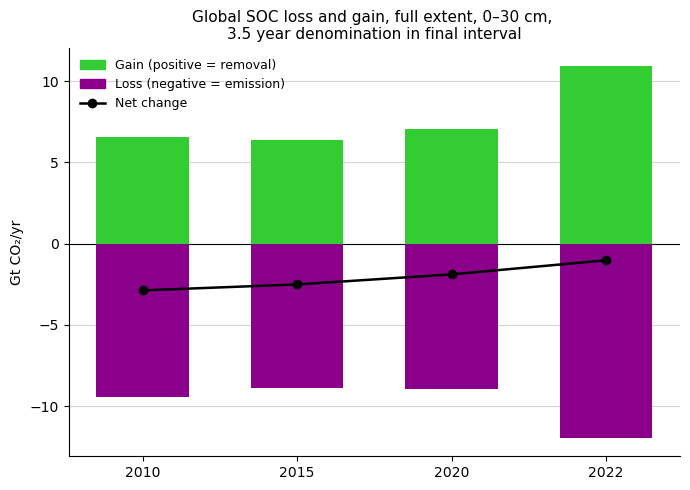

,SOC_loss__full_extent__0-30cm_MgCO2,SOC_gain__full_extent__0-30cm_MgCO2,SOC_net__full_extent__0-30cm_MgCO2
year,,,
2010,9.461,-6.590,2.872
2015,8.893,-6.386,2.507
2020,8.951,-7.063,1.888
2022,11.936,-10.913,1.023


,Ann. gain 2020 (Gt/yr),Ann. gain 2022 (Gt/yr),Gain ratio (2022/2020),Ann. loss 2020 (Gt/yr),Ann. loss 2022 (Gt/yr),Loss ratio (2022/2020)
adm0,,,,,,
VAT,-0.0,-0.0,6.748,0.0,0.0,0.285
MCO,-0.0,-0.0,5.500,0.0,0.0,0.356
UMI,-0.0,-0.0,3.990,0.0,0.0,0.426
GIB,-0.0,-0.0,1.993,0.0,0.0,0.827
BMU,-0.0,-0.0,2.526,0.0,0.0,0.645
BLM,-0.0,-0.0,4.187,0.0,0.0,0.639
SMR,-0.0,-0.0,1.544,0.0,0.0,1.294
SXM,-0.0,-0.0,1.962,0.0,0.0,0.907
MAF,-0.0,-0.0,2.843,0.0,0.0,0.807


In [31]:
### Global SOC gross loss and gain by interval: full extent only (gain positive, loss negative, counter to LULUCF convention)
### Per Claude session 'Global SOC loss/gain by year'

# ── Data ─────────────────────────────────────────────────────────────────────
FULL_LOSS = 'SOC_loss__full_extent__0-30cm_MgCO2'
FULL_GAIN = 'SOC_gain__full_extent__0-30cm_MgCO2'
FULL_NET  = 'SOC_net__full_extent__0-30cm_MgCO2'

df_soc = SOC_df_raw[SOC_df_raw['analysis_layer'].isin([FULL_LOSS, FULL_GAIN, FULL_NET])].copy()

year_totals = (
    df_soc
    .groupby(['year', 'analysis_layer'])['zonal_stats_sum']
    .sum()
    .div(1e9)
    .unstack('analysis_layer')
    .rename_axis(None, axis=1)
    .sort_index()
)

years = year_totals.index.tolist()
x = np.arange(len(years))

# Flip signs: gain → positive, loss → negative, net → flipped accordingly
loss_vals = -year_totals[FULL_LOSS].values   # was positive, now negative
gain_vals = -year_totals[FULL_GAIN].values   # was negative, now positive
net_vals  = -year_totals[FULL_NET].values

# Scale final interval: ×2 ÷ 3.5
# In the original geoprocessing, I incorrectly divided the 2022 change block by 2 to annualize instead of dividing by 3.5. This correct that. 
loss_vals[-1] = loss_vals[-1] * 2 / 3.5
gain_vals[-1] = gain_vals[-1] * 2 / 3.5
net_vals[-1]  = net_vals[-1]  * 2 / 3.5

# ── Colors (distinct for this figure) ────────────────────────────────────────
C_LOSS = "#8b008b"   # dark magenta — loss (emission)
C_GAIN = "#33cc33"   # bright green — gain (removal)
C_NET  = "#000000"   # black   — net

# ── Plot ──────────────────────────────────────────────────────────────────────
bar_w = 0.6

fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(x, loss_vals, width=bar_w, color=C_LOSS, zorder=2, label='Loss')
ax.bar(x, gain_vals, width=bar_w, color=C_GAIN, zorder=2, label='Gain')
ax.plot(x, net_vals, color=C_NET, marker='o', linewidth=1.8, zorder=4, label='Net change')

ax.axhline(0, color='black', linewidth=0.8, zorder=1)
ax.yaxis.grid(True, color='lightgrey', linewidth=0.8)
ax.set_axisbelow(True)

ax.set_xticks(x)
ax.set_xticklabels(years)
ax.set_ylabel('Gt CO₂/yr')
ax.set_title('Global SOC loss and gain, full extent, 0–30 cm, \n3.5 year denomination in final interval', fontsize=11)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

legend_handles = [
    mpatches.Patch(color=C_GAIN, label='Gain (positive = removal)'),
    mpatches.Patch(color=C_LOSS, label='Loss (negative = emission)'),
    plt.Line2D([0], [0], color=C_NET, marker='o', linewidth=1.8, label='Net change'),
]
ax.legend(handles=legend_handles, frameon=False, fontsize=9)

plt.tight_layout()
# plt.savefig(f'{LULUCF_zonal_stats_folder}/SOC_loss_gain_full_extent_{today}.jpg', dpi=300, bbox_inches='tight')
plt.show()

year_totals_display = year_totals.copy()
year_totals_display.iloc[-1] *= 2 / 3.5   # annualise final interval to match chart
display(year_totals_display[[FULL_LOSS, FULL_GAIN, FULL_NET]].round(3))


# ── Country-level ratio table: annualized 2022 vs annualized 2020 ─────────────
# To understand in which countries the jump in gross loss and gain in the last change interval is occurring 
COUNTRY_COL   = 'adm0'   

df_ctry = (
    SOC_df_raw[
        SOC_df_raw['analysis_layer'].isin([FULL_LOSS, FULL_GAIN]) &
        SOC_df_raw['year'].isin([2020, 2022])
    ]
    .groupby([COUNTRY_COL, 'year', 'analysis_layer'])['zonal_stats_sum']
    .sum()
    .unstack(['year', 'analysis_layer'])
)
df_ctry.columns = [f'{yr}_{lyr}' for yr, lyr in df_ctry.columns]

# Annualise: 2022 → ×2÷3.5 (matches chart scaling-- which has incorrectly divided the 2022 change block by 2 to annualize instead of 3.5); 2020 → is already annualized
ann_gain_2020 = df_ctry[f'2020_{FULL_GAIN}'] 
ann_gain_2022 = df_ctry[f'2022_{FULL_GAIN}'] * 2 / 3.5
ann_loss_2020 = df_ctry[f'2020_{FULL_LOSS}'] 
ann_loss_2022 = df_ctry[f'2022_{FULL_LOSS}'] * 2 / 3.5

ratio_table = pd.DataFrame({
    'Ann. gain 2020 (Gt/yr)': ann_gain_2020 / 1e9,
    'Ann. gain 2022 (Gt/yr)': ann_gain_2022 / 1e9,
    'Gain ratio (2022/2020)':  ann_gain_2022 / ann_gain_2020,
    'Ann. loss 2020 (Gt/yr)': ann_loss_2020 / 1e9,
    'Ann. loss 2022 (Gt/yr)': ann_loss_2022 / 1e9,
    'Loss ratio (2022/2020)':  ann_loss_2022 / ann_loss_2020,
}).sort_values('Ann. gain 2020 (Gt/yr)', ascending=False)

display(ratio_table.round(3).head(10))

In [ ]:
# Converts SOC table from long to wide format

SOC_df_post_2016_years_filled_in_wide = global_long_to_wide(SOC_df_post_2016_years_filled_in, agg_layers, chunk_col='cont_eco')
SOC_df_post_2016_years_filled_in_wide.to_parquet(f'{SOC_zonal_stats_folder}SOC_v{cn.SOC_model_version_underscore}__post_2016__all_vars__wide__{today}.parquet', index=False)
display(SOC_df_post_2016_years_filled_in_wide)

In [ ]:
%%time
### Standardizes organic soil table with vegetation table (already in wide format)

# Reads organic soil zonal stats parquet table
org_soil_raw_wide = pd.read_parquet(f'{org_soil_zonal_stats_folder}{org_soil_parquet_name}')
org_soil_raw_wide
print(f"Rows in org_soil_raw_wide: {len(org_soil_raw_wide)}")

# Makes table columns generally match vegetation and SOC
org_soil_adjusted_wide = org_soil_raw_wide.drop(columns=['gadm_adm0', 'country', 'inventory_period', 'interval_start', 'land_use', 'drainage_class', 
                                                         'drained_state_meaning', 'burned_state_meaning', 'combined_state_nodes',
                                                         'drained_state_nodes', 'burned_state_nodes'])
display(org_soil_adjusted_wide.columns)

# Renames columns to match vegetation names
org_soil_adjusted_wide.rename(columns={'iso3': 'adm0', 
                                'component': 'analysis_layer',
                                'interval_end': 'year',
                                'river_basins': 'watershed',
                                'wdpa': 'WDPA',
                                'kba': 'KBA',
                                'landmark': 'Landmark',
                                'primary_forest_2001': 'starting_composite_primary_forest', # TODO not necessary when Erin corrects this contextual layer
                                'area__ha': 'org_soil__area_ha'},
                       inplace=True)

# Fills NaN (empty) values with 0s
org_soil_adjusted_wide = org_soil_adjusted_wide.fillna(0)
# org_soil_adjusted_wide

# Renames columns
org_soil_adjusted_wide.columns = org_soil_adjusted_wide.columns.str.replace('_Mg_CO2', '__MgCO2')
org_soil_adjusted_wide.columns = org_soil_adjusted_wide.columns.str.replace('drained', 'org_soil_drained')
org_soil_adjusted_wide.columns = org_soil_adjusted_wide.columns.str.replace('burned', 'org_soil_burned')

# Adds attribute columns that are derived from existing columns. This is done in create_df() in zonal_stats_utilities.py for the vegetation and SOC data. 
org_soil_adjusted_wide['country_name'] = org_soil_adjusted_wide[cn.adm0_pattern].map(cn.iso_to_country)
org_soil_adjusted_wide['region_L1'] = org_soil_adjusted_wide[cn.adm0_pattern].map(cn.iso_to_region_UN_geoscheme_L1)
org_soil_adjusted_wide['region_L2_L3'] = org_soil_adjusted_wide[cn.adm0_pattern].map(cn.iso_to_region_UN_geoscheme_L2_L3)

# Because some rows for contextual layers may be blank
org_soil_adjusted_wide[cn.adm0_pattern] = org_soil_adjusted_wide[cn.adm0_pattern].fillna("Unassigned")
org_soil_adjusted_wide['country_name'] = org_soil_adjusted_wide['country_name'].fillna("Unassigned")
org_soil_adjusted_wide['region_L1'] = org_soil_adjusted_wide['region_L1'].fillna("Unassigned")
org_soil_adjusted_wide['region_L2_L3'] = org_soil_adjusted_wide['region_L2_L3'].fillna("Unassigned")

org_soil_adjusted_wide["climate_domain"] = org_soil_adjusted_wide["climate_domain"].replace({         
    "tropical": "Subtropical/tropical",
    "temperate": "Temperate",
    "boreal": "Boreal",
    "Unspecified": "Unassigned",
    "other_domain": "Unassigned"
})

org_soil_adjusted_wide['watershed_name'] = org_soil_adjusted_wide[cn.watersheds_pattern].map(cn.watershed_to_text)
org_soil_adjusted_wide["watershed_name"] = org_soil_adjusted_wide["watershed_name"].fillna("Unassigned")

org_soil_adjusted_wide['WDPA_type'] = org_soil_adjusted_wide[cn.WDPA_pattern].map(cn.WDPA_to_text)

# Per https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c-afolu-flux-model/c/69aee45e-ce6c-8325-b1d0-a6c6b0e7ae2e
org_soil_adjusted_wide["WDPA_high_protection"] = "Other protection status"

org_soil_adjusted_wide.loc[org_soil_adjusted_wide["WDPA_type"] == "NA", "WDPA_high_protection"] = "Not protected"
org_soil_adjusted_wide.loc[org_soil_adjusted_wide["WDPA_type"].isin(["Category Ia", "Category Ib", "Category II", "Category III"]), "WDPA_high_protection"] = "High protection"

org_soil_adjusted_wide['driver_1km_text'] = org_soil_adjusted_wide[cn.drivers_of_loss_pattern].map(cn.drivers_to_text)
org_soil_adjusted_wide['driver_1km_text'] = org_soil_adjusted_wide['driver_1km_text'].fillna("Unassigned")
# org_soil_adjusted_wide

# Reaggregates by remaining contextual columns after dropped columns are removed
analysis_cols = [col for col in org_soil_adjusted_wide.columns if 'MgCO2' in col] + ['org_soil__area_ha']
contextual_cols_adj = [col for col in org_soil_adjusted_wide.columns if col not in analysis_cols]
org_soil_adjusted_wide = (
    org_soil_adjusted_wide
    .groupby(contextual_cols_adj, dropna=False)[analysis_cols]
    .sum()
    .reset_index()
)
print(f"Rows in org_soil_adjusted_wide after reaggregation: {len(org_soil_adjusted_wide)}")

# Drops all years before vegetation data (before 2016) because we don't need those for LULUCF (i.e. keeps only the 2020 and 2022 stock and change data)
org_soil_post_2016_wide = org_soil_adjusted_wide[org_soil_adjusted_wide["year"] >= cn.interval_end_years_annual[0]].reset_index(drop=True)
print(f"Rows in org_soil_post_2016_wide: {len(org_soil_post_2016_wide)}")
org_soil_post_2016_wide


## Fills in the years for multi-year interval organic soil data.
# 2020 is copied to 2016-2020 and 2022 to 2021-2024 (to match end of vegetation timeseries). 
# If a year doesn't have data for a given year and combination of contextual layers, there is nothing to expand and all years in that interval are empty.
analysis_cols = [col for col in org_soil_post_2016_wide.columns if 'Mg_CO2' in col] + ['org_soil__area_ha'] # Identifies non-contextual columns
contextual_cols = org_soil_post_2016_wide.drop(columns=analysis_cols).columns.to_list()
# display(series_cols)
org_soil_post_2016_filled_in_wide = fill_in_soil_years(org_soil_post_2016_wide, contextual_cols, agg_first=False)
print(f"Rows in org_soil_post_2016_filled_in_wide: {len(org_soil_post_2016_filled_in_wide)}")

# Ratio below Should be very close to 4.5. If every contextual combination has every year, full year expansion would be 4.5 (2020 interval expanded 5x years, 2022 expanded 4x years).
# However, some contextual combinations don't have all years (usually because they're so rare and other years have just 1 pixel of that combination),
# so that doesn't get expanded to other years. This results in deviation from the 4.25x expansion. 
print(f"Ratio of rows in unexpanded to expanded tables: {len(org_soil_post_2016_filled_in_wide)/len(org_soil_post_2016_wide)}")

# Adds contextual columns found in the vegetation table. Fills with Unassigned for text fields and -999 for numeric fields.
# Gets the data type for the fields from the vegetation table
veg_parquet_path = f'{veg_zonal_stats_folder}veg_model_zonal_stats__global__v{cn.veg_model_version_underscore}__all_layers__wide__20260605.parquet'
veg_field_types = {field.name: field.type for field in pq.read_schema(veg_parquet_path)}
contextual_cols = [c for c in agg_layers if c != 'analysis_layer']
for col in contextual_cols:
    if col not in org_soil_post_2016_filled_in_wide.columns:
        arrow_type = veg_field_types.get(col)
        is_numeric = arrow_type is not None and (pa.types.is_integer(arrow_type) or pa.types.is_floating(arrow_type))
        default = -999 if is_numeric else 'Unassigned'
        org_soil_post_2016_filled_in_wide[col] = default
        print(f"  Adding {col} with default of {default}")

# Recasts float64 columns to float32 columns. Vegetation and SOC are already float32.
org_soil_post_2016_filled_in_wide[org_soil_post_2016_filled_in_wide.select_dtypes('float64').columns] = org_soil_post_2016_filled_in_wide.select_dtypes('float64').astype('float32')

# Information on the years included in the table
org_soil_year_count = len(org_soil_post_2016_filled_in_wide['year'].unique())
print(f"Years in organic soil data: {org_soil_post_2016_filled_in_wide['year'].unique()} is {org_soil_year_count} years")

org_soil_post_2016_filled_in_wide.to_csv(f"{org_soil_zonal_stats_folder}org_soil__post_2016__all_vars__wide__{today}.csv", index=False)
org_soil_post_2016_filled_in_wide.to_parquet(f"{org_soil_zonal_stats_folder}org_soil__post_2016__all_vars__wide__{today}.parquet", index=False)
org_soil_post_2016_filled_in_wide

### Create combined LULUCF table (wide format)

In [ ]:
# Read only the small tables into pandas
SOC_df_post_2016_years_filled_in_wide  = pd.read_parquet(f'{SOC_zonal_stats_folder}SOC_v{cn.SOC_model_version_underscore}__post_2016__all_vars__wide__20260606.parquet')
org_soil_post_2016_filled_in_wide      = pd.read_parquet(f"{org_soil_zonal_stats_folder}org_soil__post_2016__all_vars__wide__20260606.parquet")

# veg stays on disk — reference only the path to keep it out of memory
veg_parquet_path = f'{veg_zonal_stats_folder}veg_model_zonal_stats__global__v{cn.veg_model_version_underscore}__all_layers__wide__20260605.parquet'
veg_schema = pq.read_schema(veg_parquet_path)
all_veg_cols = veg_schema.names
veg_metadata = pq.read_metadata(veg_parquet_path)
veg_row_count = veg_metadata.num_rows

SOC_table_shape = SOC_df_post_2016_years_filled_in_wide.shape
org_soil_table_shape = org_soil_post_2016_filled_in_wide.shape

print(f"Dimensions of SOC table:      {SOC_table_shape}")
print(f"Dimensions of org soil table: {org_soil_table_shape}")
print(f"Veg rows: {veg_row_count:,}")
print(f"Veg column names ({len(all_veg_cols)} columns): {all_veg_cols}")

In [ ]:
# Confirms that vegetation, SOC and organic soil tables have the right columns and the right options in each column
# Also, establishes contextual columns for each table

print(f"Columns in vegetation table are: {all_veg_cols}")
# Non-contexual column identifier strings
keep_strings = ['MgC', 'emission_factor']
veg_analysis_cols = [
    col for col in all_veg_cols
    if any(s in col for s in keep_strings)
]
# Contextual cols are everything that isn't a flux or area analysis column
veg_contextual_cols = [c for c in all_veg_cols if c not in veg_analysis_cols]
print(f"Contextual columns are: {veg_contextual_cols}")

print("\n")
print(f"Columns in mineral soil table are: {SOC_df_post_2016_years_filled_in_wide.columns}")
SOC_analysis_cols = [col for col in SOC_df_post_2016_years_filled_in_wide.columns if 'MgC' in col] # Identifies non-contextual columns
SOC_contextual_cols = SOC_df_post_2016_years_filled_in_wide.drop(columns=SOC_analysis_cols).columns.to_list()  # Identifies contextual col
print(f"Contextual columns are: {SOC_contextual_cols}")
# for column in SOC_contextual_cols:
#     print(f"{column}: {np.sort(SOC_df_post_2016_years_filled_in_wide[column].unique())}")

print("\n")
print(f"Columns in organic soil table are: {org_soil_post_2016_filled_in_wide.columns}")
org_soil_analysis_cols = [col for col in org_soil_post_2016_filled_in_wide.columns if 'MgC' in col] + ["org_soil__area_ha"]  # Identifies non-contextual columns
org_soil_contextual_cols = org_soil_post_2016_filled_in_wide.drop(columns=org_soil_analysis_cols).columns.to_list()  # Identifies contextual col
print(f"Contextual columns are: {org_soil_contextual_cols}")
# for column in org_soil_contextual_cols:
#     print(f"{column}: {np.sort(org_soil_post_2016_filled_in_wide[column].unique())}")

In [ ]:
%%time
# Pandas couldn't handle merging the three component tables (mostly because vegetation is so large). 
# This uses an alternative approach where less is kept in memory by joining the three component tables one year at a time, then merging all years back together.
# Takes roughly 8.5 minutes

shared_contextual_cols = veg_contextual_cols
chunks_dir = f'{LULUCF_zonal_stats_folder}/year_chunks_global/'
os.makedirs(chunks_dir, exist_ok=True)

# Cast join keys to str in the two small in-memory tables
for col in shared_contextual_cols:
    SOC_df_post_2016_years_filled_in_wide[col]  = SOC_df_post_2016_years_filled_in_wide[col].astype(str)
    org_soil_post_2016_filled_in_wide[col]   = org_soil_post_2016_filled_in_wide[col].astype(str)

years = sorted(pd.read_parquet(veg_parquet_path, columns=['year'])['year'].unique())
print(f"Processing {len(years)} years: {years}")

for year in years:
    out_path = f'{chunks_dir}year_{year}.parquet'
    if os.path.exists(out_path):
        print(f"  Year {year}: already done, skipping")
        continue

    print(f"  Year {year}...")
    veg_year = pd.read_parquet(veg_parquet_path, filters=[('year', '==', year)])
    for col in shared_contextual_cols:
        veg_year[col] = veg_year[col].astype(str)

    soc_year = SOC_df_post_2016_years_filled_in_wide[SOC_df_post_2016_years_filled_in_wide['year'] == str(year)]
    org_year = org_soil_post_2016_filled_in_wide[org_soil_post_2016_filled_in_wide['year'] == str(year)]

    chunk = (
        veg_year
        .merge(soc_year, on=shared_contextual_cols, how='outer')
        .merge(org_year,  on=shared_contextual_cols, how='outer')
    )
    chunk.to_parquet(out_path, index=False)
    print(f"    {len(chunk):,} rows → saved to {out_path}")
    del veg_year, soc_year, org_year, chunk; gc.collect()

# Combine year chunks from disk
print("Combining year chunks...")
LULUCF_wide = pd.concat(
    [pd.read_parquet(f) for f in sorted(glob.glob(f'{chunks_dir}year_*.parquet'))],
    ignore_index=True
)

all_analysis_cols = veg_analysis_cols + SOC_analysis_cols + org_soil_analysis_cols
LULUCF_wide[all_analysis_cols] = LULUCF_wide[all_analysis_cols].fillna(0)

print(f"Rows in LULUCF_wide: {len(LULUCF_wide):,}")
LULUCF_wide.to_parquet(f"{LULUCF_zonal_stats_folder}/LULUCF__v{cn.LULUCF_model_version_underscore}__no_LULUCF_summative_vars__wide__{today}.parquet", index=False)
display(LULUCF_wide.head())

In [ ]:
# Counts the rows in the three wide component tables and the full LULUCF table. They should match since the three component tables share no contextual layer combinations
indiv_table_row_sum = veg_row_count + SOC_table_shape[0] + org_soil_table_shape[0]
print(f"indiv_table_row_sum: {indiv_table_row_sum}")
print(f"LULUCF_wide.shape: {LULUCF_wide.shape}")

In [ ]:
# All columns in the LULUCF table
# print(LULUCF_wide.columns)
LULUCF_analysis_cols = [col for col in LULUCF_wide.columns 
                        if any(term in col for term in ['MgC', 'fraction', 'area'])]  # Identifies non-contextual columns
LULUCF_contextual_cols = LULUCF_wide.drop(columns=LULUCF_analysis_cols).columns.to_list()  # Identifies contextual columns
print(f"Contextual columns are: {LULUCF_contextual_cols}")
for column in LULUCF_contextual_cols:
    print(f"{column}: {np.sort(LULUCF_wide[column].unique())}")

In [ ]:
# LULUCF-level gross and net sum columns added to wide LULUCF table
# This needs to run without any other cells have run in the same kernel because it takes so much memory.

print("Reading LULUCF_wide parquet")
LULUCF_wide  = pd.read_parquet(f"{LULUCF_zonal_stats_folder}/LULUCF__v{cn.LULUCF_model_version_underscore}__no_LULUCF_summative_vars__wide__{today}.parquet")

print(f"Creating soil emissions columns")
LULUCF_wide['org_soil_emis_total__MgCO2e'] = LULUCF_wide['org_soil_drained_total__MgCO2e'] + LULUCF_wide['org_soil_burned_total__MgCO2e']
LULUCF_wide['soil_emis_total__MgCO2e'] = LULUCF_wide['org_soil_emis_total__MgCO2e'] + LULUCF_wide['SOC_loss__mineral_soil_extent__0-30cm_MgCO2']

print(f"Creating summative emissions columns")
LULUCF_wide['LULUCF_gross_emissions__CO2__MgCO2'] = LULUCF_wide['gross_emissions__all_C_pools__CO2_only__MgCO2'] + LULUCF_wide['org_soil_drained_total_co2__MgCO2'] + LULUCF_wide['org_soil_burned_total_co2__MgCO2']
LULUCF_wide['LULUCF_gross_emissions__CH4__MgCO2e'] = LULUCF_wide['gross_emissions__CH4__MgCO2e'] + LULUCF_wide['org_soil_drained_total_ch4__MgCO2e'] + LULUCF_wide['org_soil_burned_total_ch4__MgCO2e']
LULUCF_wide['LULUCF_gross_emissions__N2O__MgCO2e'] = LULUCF_wide['gross_emissions__N2O__MgCO2e'] + LULUCF_wide['org_soil_drained_n2o__MgCO2e']
LULUCF_wide['LULUCF_gross_emissions__non_CO2__MgCO2e'] = LULUCF_wide['LULUCF_gross_emissions__CH4__MgCO2e'] + LULUCF_wide['LULUCF_gross_emissions__N2O__MgCO2e'] 
LULUCF_wide['LULUCF_gross_emissions__all_gases__MgCO2e'] = LULUCF_wide['gross_emissions__all_C_pools__all_gases__MgCO2e'] + LULUCF_wide['soil_emis_total__MgCO2e']

print(f"Creating summative removals column")
LULUCF_wide['LULUCF_gross_removals__MgCO2'] = LULUCF_wide['gross_removals__all_C_pools__MgCO2'] + LULUCF_wide['SOC_gain__mineral_soil_extent__0-30cm_MgCO2']

print(f"Creating summative net flux column")
LULUCF_wide['LULUCF_net_flux__MgCO2e'] = LULUCF_wide['LULUCF_gross_emissions__all_gases__MgCO2e'] + LULUCF_wide['LULUCF_gross_removals__MgCO2']

print("Saving to parquet in year batches...")
LULUCF_wide_with_LULUCF_cols = LULUCF_wide  # alias, no copy
out_path = f'{LULUCF_zonal_stats_folder}/LULUCF__v{cn.LULUCF_model_version_underscore}__LULUCF_summative_vars__wide__{today}.parquet'
years_sorted = sorted(LULUCF_wide_with_LULUCF_cols['year'].unique())

# Infer schema from first real chunk, not an empty slice
first_chunk = LULUCF_wide_with_LULUCF_cols[LULUCF_wide_with_LULUCF_cols['year'] == years_sorted[0]]
schema = pa.Table.from_pandas(first_chunk, preserve_index=False).schema

with pq.ParquetWriter(out_path, schema) as writer:
    for year in years_sorted:
        chunk = LULUCF_wide_with_LULUCF_cols[LULUCF_wide_with_LULUCF_cols['year'] == year]
        writer.write_table(pa.Table.from_pandas(chunk, schema=schema, preserve_index=False))
        print(f"  Year {year}: {len(chunk):,} rows written")

print("Done")

In [9]:
# Columns for full LULUCF table

LULUCF_parquet_path = f'{LULUCF_zonal_stats_folder}/LULUCF__v1_0_0__LULUCF_summative_vars__wide__20260606.parquet'
LULUCF_schema = pq.read_schema(LULUCF_parquet_path)
all_LULUCF_cols = LULUCF_schema.names
print(all_LULUCF_cols)

pf = pq.read_metadata(LULUCF_parquet_path)
LULUCF_row_count = pf.num_rows
print(f"LULUCF rows: {LULUCF_row_count:,}")

['year', 'land_state_node', 'land_state_meaning', 'land_state_broad_class', 'land_state_detailed_class', 'tall_veg_type', 'adm0', 'country_name', 'region_L1', 'region_L2_L3', 'continent', 'ecozone', 'continent_ecozone', 'climate_domain', 'cont_eco', 'Landmark', 'starting_composite_primary_forest', 'KBA', 'watershed', 'watershed_name', 'drivers_of_TCL_1_km', 'driver_1km_text', 'forest_age_category_end_of_interval', 'WDPA', 'WDPA_type', 'WDPA_high_protection', 'AGC_emission_factor_CO2_only__fraction', 'carbon_density__non_soil__MgC_ha', 'gross_emissions__AGC__MgCO2', 'gross_emissions__BGC__MgCO2', 'gross_emissions__CH4__MgCO2e', 'gross_emissions__N2O__MgCO2e', 'gross_emissions__all_C_pools__CO2_only__MgCO2', 'gross_emissions__all_C_pools__all_gases__MgCO2e', 'gross_emissions__all_C_pools__non_CO2_only__MgCO2e', 'gross_emissions__deadwood_C__MgCO2', 'gross_emissions__litter_C__MgCO2', 'gross_removals__AGC__MgCO2', 'gross_removals__BGC__MgCO2', 'gross_removals__all_C_pools__MgCO2', 'gross_

In [9]:
# Simplified LULUCF table (wide-format) for using in graphs

print("Reading parquet")
LULUCF_wide_with_LULUCF_cols  = pd.read_parquet(f"{LULUCF_zonal_stats_folder}/LULUCF__v{cn.LULUCF_model_version_underscore}__LULUCF_summative_vars__wide__20260606.parquet")
LULUCF_analysis_cols = [col for col in LULUCF_wide_with_LULUCF_cols.columns 
                        if any(term in col for term in ['MgC', 'fraction', 'area'])]  # Identifies non-contextual columns

print("Regrouping parquet")
LULUCF_for_figures = (
    LULUCF_wide_with_LULUCF_cols
    .groupby(['country_name', 'adm0', 'region_L1', 'region_L2_L3', 
              'year',
              'land_state_node', 'land_state_meaning', 'land_state_broad_class', 'land_state_detailed_class', 'tall_veg_type',
              'climate_domain'], dropna=False)[LULUCF_analysis_cols]
    .sum()
    .reset_index()
)
print(LULUCF_for_figures.shape)
LULUCF_for_figures.to_parquet(f"{LULUCF_zonal_stats_folder}/LULUCF__v{cn.LULUCF_model_version_underscore}__for_figures__wide__{today}.parquet", index=False)

Reading parquet
Regrouping parquet
(122666, 92)


### QC: Checking if values in final LULUCF table match original tables for each component (chunk stats for veg and SOC, input wide table for organic soil)

In [ ]:
# Vegetation chunk stats output (for comparison with zonal stats)
veg_chunk_stats_folder = f'/mnt/c/GIS/git/AFOLU_GHG_flux_model/chunk_stats/parquet_20260131_10_37_46__KEEP/'
veg_gross_outputs_parquet = f'{veg_chunk_stats_folder}vegetation_fluxes_20260131_10_37_28__v1_0_5__gross_outputs_1x1.parquet'
veg_net_outputs_parquet = f'{veg_chunk_stats_folder}vegetation_fluxes_20260131_10_37_28__v1_0_5__net_outputs_1x1.parquet'
veg_chunk_stats_gross = pd.read_parquet(veg_gross_outputs_parquet)
veg_chunk_stats_net = pd.read_parquet(veg_net_outputs_parquet)
# Combine gross and net chunk stats, aggregate to 10x10 deg tile level
veg_chunk_stats_combined = pd.concat([veg_chunk_stats_gross, veg_chunk_stats_net], ignore_index=True)

In [ ]:
### Compares global annual veg fluxes in final, simplified LULUCF table against original vegetation chunk stats table.
### Uses the simplified LULUCF table rather than the full one because the full one really pushes memory. 
### I expect that chunk stats and zonal stats will differ somewhat for emissions. Emissions chunk stats should be lower because when I ran veg v1.0.5 and got chunk stats, 
### chunk stats summing still didn't sum in chunks with NaN pixels and maybe had other issues.
### So, chunk stats should be lower than zonal stats for emissions in general.
### Also, chunk stats uses the original global run of v1.0.5, which doesn't include the re-run tiles in Canada that included the missing emission factor for partial disturbance,
### so chunk stats also uses slightly older data that is actually missing emissions compared to zonal stats (that integrates the Canada re-run). 

### Chunk stats

# Chunk stats summed across all tiles
print("Summing chunk stats across tiles")
veg_chunk_tile_agg = (
    veg_chunk_stats_combined
    .groupby(['pattern', 'years'], dropna=False)['sum_value']
    .sum()
    .reset_index()
    .rename(columns={'years': 'year', 'pattern': 'variable', 'sum_value': 'tile_sum'})
)
veg_chunk_tile_agg['year'] = veg_chunk_tile_agg['year'].astype(int)
veg_chunk_tile_agg.rename(columns={'variable': 'analysis_layer', 'tile_sum': 'chunk_stats_sum'}, inplace=True)
veg_chunk_tile_agg

# Reference: veg chunk stats -- sum across all tiles by year and analysis_layer
print("Aggregating chunk stats across tiles")
chunk_veg_ref = (
    veg_chunk_tile_agg
    .groupby(['year', 'analysis_layer'])['chunk_stats_sum']
    .sum()
    .unstack('analysis_layer')
    .rename_axis(None, axis='columns')
    .rename(columns=lambda col: col.replace('_ha_yr', ''))
    .sort_index()
)
chunk_veg_ref.index = chunk_veg_ref.index.astype(int)
print("chunk stats")
display(chunk_veg_ref)


### Final LULUCF table (zonal stats)

LULUCF_for_figures  = pd.read_parquet(f"{LULUCF_zonal_stats_folder}/LULUCF__v{cn.LULUCF_model_version_underscore}__for_figures__wide__20260605.parquet")
LULUCF_analysis_cols = [col for col in LULUCF_for_figures.columns 
                        if any(term in col for term in ['MgC', 'fraction', 'area'])]  # Identifies non-contextual columns

# From LULUC simplified for figures -- veg flux columns only, summed globally by year
flux_cols_veg = [col for col in LULUCF_analysis_cols if '__area_ha' not in col]
LULUCF_veg_by_year = (
    LULUCF_for_figures
    .groupby('year')[flux_cols_veg]
    .sum()
    .sort_index()
)
LULUCF_veg_by_year.index = LULUCF_veg_by_year.index.astype(int)
print("final zonal stats")
display(LULUCF_veg_by_year)


### Comparison

# Only compare columns that exist in both (chunk stats may not have all layers)
shared_cols = [col for col in flux_cols_veg if col in chunk_veg_ref.columns]
print(f"Comparing {len(shared_cols)} shared analysis layers")
print(f"Layers in LULUCF_for_figures but not chunk stats: {set(flux_cols_veg) - set(chunk_veg_ref.columns)}")
print(f"Layers in chunk stats but not LULUCF_for_figures: {set(chunk_veg_ref.columns) - set(flux_cols_veg)}")

diff = LULUCF_veg_by_year[shared_cols] - chunk_veg_ref[shared_cols]
pct_diff = (diff / chunk_veg_ref[shared_cols].abs() * 100).round(4)

print("\n=== Absolute difference (zonal stats minus chunk stats) ===")
display(diff)
print("\n=== Percent difference (positive is zonal stats being > chunk stats) ===")
display(pct_diff)

In [20]:
# SOC chunk stats output (for comparison with zonal stats)
SOC_chunk_stats_file = f'/mnt/c/GIS/git/AFOLU_GHG_flux_model/chunk_stats/KEEP_definitive_runs/SOC_density/v1_0_1__2000_2022_revised_org_soil__20260526/soil_carbon_densities_and_changes_1x1_chunk_statistics_20260526_15_43_37__KEEP.xlsx'
SOC_chunk_stats_gross = pd.read_excel(SOC_chunk_stats_file, sheet_name='other_outputs_1x1')
SOC_chunk_stats_net = pd.read_excel(SOC_chunk_stats_file, sheet_name='net_outputs_1x1')
# Combine gross and net chunk stats, aggregate to 10x10 deg tile level
SOC_chunk_stats_combined = pd.concat([SOC_chunk_stats_gross, SOC_chunk_stats_net], ignore_index=True)

In [22]:
### Compares global annual SOC fluxes in final, simplified LULUCF table against original SOC chunk stats table.
### Uses the simplified LULUCF table rather than the full one because the full one really pushes memory. 
### I expect that SOC chunk stats and zonal stats should be pretty much identical. 


### Chunk stats

# Chunk stats summed across all tiles
SOC_chunk_tile_agg = (
    SOC_chunk_stats_combined
    .groupby(['pattern', 'years'], dropna=False)['sum_value']
    .sum()
    .reset_index()
    .rename(columns={'years': 'year', 'pattern': 'variable', 'sum_value': 'tile_sum'})
)
SOC_chunk_tile_agg['year'] = SOC_chunk_tile_agg['year'].astype(int)
SOC_chunk_tile_agg.rename(columns={'variable': 'analysis_layer', 'tile_sum': 'chunk_stats_sum'}, inplace=True)

# Final LULUCF table has only post-2016 soil data, so need to limit chunk stats for comparison
SOC_chunk_tile_agg_post_2016 = SOC_chunk_tile_agg[SOC_chunk_tile_agg["year"] >= cn.interval_end_years_annual[0]].reset_index(drop=True)
SOC_chunk_tile_agg_post_2016

# Reference: SOC chunk stats -- sum across all tiles by year and analysis_layer
chunk_SOC_ref = (
    SOC_chunk_tile_agg_post_2016
    .groupby(['year', 'analysis_layer'])['chunk_stats_sum']
    .sum()
    .unstack('analysis_layer')
    .rename_axis(None, axis='columns')
    .rename(columns=lambda col: col.replace('_ha_yr', ''))
    .sort_index()
)
chunk_SOC_ref.index = chunk_SOC_ref.index.astype(int)
print("chunk stats")
display(chunk_SOC_ref)


### Final LULUCF table (zonal stats)

LULUCF_for_figures  = pd.read_parquet(f"{LULUCF_zonal_stats_folder}/LULUCF__v{cn.LULUCF_model_version_underscore}__for_figures__wide__20260606.parquet")
LULUCF_analysis_cols = [col for col in LULUCF_for_figures.columns 
                        if any(term in col for term in ['MgC', 'fraction', 'area'])]  # Identifies non-contextual columns

# From LULUCF_for_figures -- veg flux columns only, summed globally by year
flux_cols_SOC = [col for col in LULUCF_analysis_cols if '__area_ha' not in col]
LULUCF_SOC_by_year = (
    LULUCF_for_figures
    .groupby('year')[flux_cols_SOC]
    .sum()
    .sort_index()
)
LULUCF_SOC_by_year.index = LULUCF_SOC_by_year.index.astype(int)

# Limits SOC from LULUCF table to original years
LULUCF_SOC_by_year = LULUCF_SOC_by_year.loc[[2020, 2022]]

print("final zonal stats")
display(LULUCF_SOC_by_year)


### Comparison

# Only compare columns that exist in both (chunk stats may not have all layers)
shared_cols = [col for col in flux_cols_SOC if col in chunk_SOC_ref.columns]
print(f"Comparing {len(shared_cols)} shared analysis layers")
print(f"Layers in LULUCF_for_figures but not chunk stats: {set(flux_cols_SOC) - set(chunk_SOC_ref.columns)}")
print(f"Layers in chunk stats but not LULUCF_for_figures: {set(chunk_SOC_ref.columns) - set(flux_cols_SOC)}")

diff = LULUCF_SOC_by_year[shared_cols] - chunk_SOC_ref[shared_cols]
pct_diff = (diff / chunk_SOC_ref[shared_cols].abs() * 100).round(8)

print("\n=== Absolute difference (zonal stats minus chunk stats) ===")
display(diff)
print("\n=== Percent difference (positive is zonal stats being > chunk stats) ===")
display(pct_diff)

chunk stats


,SOC_density__full_extent__0-30cm_MgC_ha,SOC_density__mineral_soil_extent__0-30cm_MgC_ha,SOC_gain__full_extent__0-30cm_MgCO2,SOC_gain__mineral_soil_extent__0-30cm_MgCO2,SOC_loss__full_extent__0-30cm_MgCO2,SOC_loss__mineral_soil_extent__0-30cm_MgCO2,SOC_net__full_extent__0-30cm_MgCO2,SOC_net__mineral_soil_extent__0-30cm_MgCO2
year,,,,,,,,
2020,4.446701e+11,3.503613e+11,-7.063454e+09,-5.495786e+09,8.951121e+09,6.760377e+09,1.887667e+09,1.264591e+09
2022,4.436921e+11,3.491311e+11,-1.909820e+10,-1.368484e+10,2.088861e+10,1.593772e+10,1.790410e+09,2.252878e+09


final zonal stats


,AGC_emission_factor_CO2_only__fraction,carbon_density__non_soil__MgC_ha,gross_emissions__AGC__MgCO2,gross_emissions__BGC__MgCO2,gross_emissions__CH4__MgCO2e,gross_emissions__N2O__MgCO2e,gross_emissions__all_C_pools__CO2_only__MgCO2,gross_emissions__all_C_pools__all_gases__MgCO2e,gross_emissions__all_C_pools__non_CO2_only__MgCO2e,gross_emissions__deadwood_C__MgCO2,gross_emissions__litter_C__MgCO2,gross_removals__AGC__MgCO2,gross_removals__BGC__MgCO2,gross_removals__all_C_pools__MgCO2,gross_removals__deadwood_C__MgCO2,gross_removals__litter_C__MgCO2,net_flux__AGC__MgCO2,net_flux__BGC__MgCO2,net_flux__all_C_pools__CO2_only__MgCO2,net_flux__all_C_pools__all_gases__MgCO2e,net_flux__deadwood_C__MgCO2,net_flux__litter_C__MgCO2,removal_factor__AGC__MgC,SOC_density__full_extent__0-30cm_MgC_ha,SOC_density__mineral_soil_extent__0-30cm_MgC_ha,SOC_gain__full_extent__0-30cm_MgCO2,SOC_gain__mineral_soil_extent__0-30cm_MgCO2,SOC_loss__full_extent__0-30cm_MgCO2,SOC_loss__mineral_soil_extent__0-30cm_MgCO2,SOC_net__full_extent__0-30cm_MgCO2,SOC_net__mineral_soil_extent__0-30cm_MgCO2,org_soil_drained_total__MgCO2e,org_soil_drained_co2_onsite__MgCO2,org_soil_drained_co2_offsite__MgCO2,org_soil_drained_total_co2__MgCO2,org_soil_drained_total_ch4__MgCO2e,org_soil_drained_n2o__MgCO2e,org_soil_burned_total__MgCO2e,org_soil_burned_total_co2__MgCO2,org_soil_burned_total_ch4__MgCO2e,organic_soil_emis_total__MgCO2e,soil_emis_total__MgCO2e,LULUCF_gross_emissions__CO2__MgCO2,LULUCF_gross_emissions__CH4__MgCO2e,LULUCF_gross_emissions__N2O__MgCO2e,LULUCF_gross_emissions__non_CO2__MgCO2e,LULUCF_gross_emissions__all_gases__MgCO2e,LULUCF_gross_removals__MgCO2,LULUCF_net_flux__MgCO2e
year,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2020,100884408.0,3.738780e+11,9.749906e+09,2.061720e+09,287361312.0,114229312.0,1.196123e+10,1.236282e+10,401590624.0,118265096.0,31335668.0,-1.399504e+10,-4.418457e+09,-1.843908e+10,-19497034.0,-6082023.0,-4.245134e+09,-2.356737e+09,-6.477849e+09,-6.076258e+09,98768064.0,25253646.0,3.937314e+09,4.446701e+11,3.503614e+11,-7.063455e+09,-5.495786e+09,8.951121e+09,6.760377e+09,1.887667e+09,1.264591e+09,2.038003e+09,1.701882e+09,101296624.0,1.803179e+09,88822448.0,146001664.0,443462112.0,359373344.0,84088776.0,2.481465e+09,9.241842e+09,1.412378e+10,460272512.0,260230960.0,720503488.0,2.160466e+10,-2.393486e+10,-2.330203e+09
2022,85781280.0,3.774195e+11,8.261025e+09,1.912891e+09,210173600.0,82306328.0,1.032154e+10,1.061402e+10,292479936.0,116996560.0,30630864.0,-1.409446e+10,-4.448691e+09,-1.858058e+10,-28095742.0,-9332863.0,-5.833435e+09,-2.535800e+09,-8.259036e+09,-7.966556e+09,88900816.0,21298002.0,3.955114e+09,4.436922e+11,3.491311e+11,-1.909820e+10,-1.368484e+10,2.088861e+10,1.593772e+10,1.790410e+09,2.252878e+09,2.128826e+09,1.764331e+09,120519504.0,1.884850e+09,86881656.0,157094304.0,540729088.0,445728640.0,95000376.0,2.669555e+09,1.860728e+10,1.265212e+10,392055616.0,239400640.0,631456256.0,2.922130e+10,-3.226542e+10,-3.044123e+09


Comparing 8 shared analysis layers
Layers in LULUCF_for_figures but not chunk stats: {'gross_removals__litter_C__MgCO2', 'gross_emissions__deadwood_C__MgCO2', 'gross_removals__deadwood_C__MgCO2', 'org_soil_drained_total_co2__MgCO2', 'org_soil_burned_total_ch4__MgCO2e', 'gross_emissions__AGC__MgCO2', 'org_soil_drained_co2_onsite__MgCO2', 'gross_emissions__all_C_pools__non_CO2_only__MgCO2e', 'LULUCF_net_flux__MgCO2e', 'AGC_emission_factor_CO2_only__fraction', 'gross_removals__AGC__MgCO2', 'gross_emissions__BGC__MgCO2', 'org_soil_burned_total__MgCO2e', 'gross_emissions__N2O__MgCO2e', 'carbon_density__non_soil__MgC_ha', 'organic_soil_emis_total__MgCO2e', 'soil_emis_total__MgCO2e', 'gross_emissions__litter_C__MgCO2', 'LULUCF_gross_emissions__CH4__MgCO2e', 'org_soil_burned_total_co2__MgCO2', 'net_flux__all_C_pools__all_gases__MgCO2e', 'gross_emissions__CH4__MgCO2e', 'net_flux__litter_C__MgCO2', 'LULUCF_gross_emissions__non_CO2__MgCO2e', 'LULUCF_gross_emissions__all_gases__MgCO2e', 'net_flux_

,SOC_density__full_extent__0-30cm_MgC_ha,SOC_density__mineral_soil_extent__0-30cm_MgC_ha,SOC_gain__full_extent__0-30cm_MgCO2,SOC_gain__mineral_soil_extent__0-30cm_MgCO2,SOC_loss__full_extent__0-30cm_MgCO2,SOC_loss__mineral_soil_extent__0-30cm_MgCO2,SOC_net__full_extent__0-30cm_MgCO2,SOC_net__mineral_soil_extent__0-30cm_MgCO2
year,,,,,,,,
2020,14497.624390,21025.929932,-473.062742,-271.633113,-100.668669,391.475938,37.407407,-5.609629
2022,9551.541443,-4073.598816,-996.286205,-284.698271,-294.545761,262.528809,166.123938,4.638460



=== Percent difference (positive is zonal stats being > chunk stats) ===


,SOC_density__full_extent__0-30cm_MgC_ha,SOC_density__mineral_soil_extent__0-30cm_MgC_ha,SOC_gain__full_extent__0-30cm_MgCO2,SOC_gain__mineral_soil_extent__0-30cm_MgCO2,SOC_loss__full_extent__0-30cm_MgCO2,SOC_loss__mineral_soil_extent__0-30cm_MgCO2,SOC_net__full_extent__0-30cm_MgCO2,SOC_net__mineral_soil_extent__0-30cm_MgCO2
year,,,,,,,,
2020,0.000003,0.000006,-0.000007,-0.000005,-0.000001,0.000006,0.000002,-4.400000e-07
2022,0.000002,-0.000001,-0.000005,-0.000002,-0.000001,0.000002,0.000009,2.100000e-07


In [ ]:
### Compares global annual organic soil fluxes in final, simplified LULUCF table against original table.
### Uses the simplified LULUCF table rather than the full one because the full one really pushes memory. 
### I expect that the original and final tables should be identical. 


### Standalone table (after standardization, to simplify comparison)

# print("Processing standalone organic soil table")
# org_soil_alone  = pd.read_parquet(f"{org_soil_zonal_stats_folder}/org_soil__post_2016__all_vars__wide__20260605.parquet")

# Reference: organic soil table summed by year
flux_cols_org_soil = [col for col in org_soil_alone.columns 
                        if any(term in col for term in ['org_soil_'])] 
org_soil_ref_by_year = (
    org_soil_alone
    .groupby('year')[flux_cols_org_soil]
    .sum()
    .sort_index()
)
org_soil_ref_by_year.index = org_soil_ref_by_year.index.astype(int)
print("standalone organic soil table")
display(org_soil_ref_by_year)


### Final LULUCF table (zonal stats)

print("Processing simplified final LULUCF table")
LULUCF_for_figures  = pd.read_parquet(f"{LULUCF_zonal_stats_folder}/LULUCF__v{cn.LULUCF_model_version_underscore}__for_figures__wide__20260605.parquet")
LULUCF_analysis_cols = [col for col in LULUCF_for_figures.columns 
                        if any(term in col for term in ['MgC', 'fraction', 'area'])]  # Identifies non-contextual columns

# From LULUCF_for_figures -- organic soil flux columns, summed globally by year
LULUCF_org_soil_by_year = (
    LULUCF_for_figures
    .groupby('year')[flux_cols_org_soil]
    .sum()
    .sort_index()
)
LULUCF_org_soil_by_year.index = LULUCF_org_soil_by_year.index.astype(int)


### Comparison

print("final zonal stats")
display(LULUCF_org_soil_by_year)

shared_cols_org_soil = [col for col in flux_cols_org_soil if col in org_soil_ref_by_year.columns]
print(f"Comparing {len(shared_cols_org_soil)} shared organic soil columns")
print(f"Columns in LULUCF_for_figures but not org soil ref: {set(flux_cols_org_soil) - set(org_soil_ref_by_year.columns)}")
print(f"Columns in org soil ref but not LULUCF_for_figures: {set(org_soil_ref_by_year.columns) - set(flux_cols_org_soil)}")

diff = LULUCF_org_soil_by_year[shared_cols_org_soil] - org_soil_ref_by_year[shared_cols_org_soil]
pct_diff = (diff / org_soil_ref_by_year[shared_cols_org_soil].abs() * 100).round(4)

print("\n=== Absolute difference (LULUCF_for_figures minus original org soil) ===")
display(diff)
print("\n=== Percent difference ===")
display(pct_diff)